In [1]:
import h5py
from functools import partial
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd

from spikeparam.patch.fit import PolySpikeGroup

# Load data
fs = 200000 

def reader(ind, alt=False):
    
    file = h5py.File('pvc-6/153098.04.02_data.h5', 'r')
    dset = file['Sweep_' + str(ind)]
    
    if alt:
        sig = dset[:, 0]
    else:
        sig = dset[:, 1]
    
    return sig

### PolySpikeGroup

`PolySpikeGroup` is a subclass of `SpikeGroup` that additionally computes a polynomial spline. The only API difference is that the former is initalized with an `orders` argument that determines the order per polynomial, and the `points` argument is used to define which points to compute polynomials between, defaulting to: 

```
['ramp_start', 'inflection', 'rise', 'peak', 'decay', 'tau', 'mtau', 'exp_end']
```

Polynomial coefficients are stored in `.df_poly` and `.poly_*` attributes, including:

`.poly_coeffs`
`.poly_fit`
`.poly_indices`
`.poly_order`
`.poly_rsqs`
`.poly_rsq_full`

In [2]:
# Fit
psg = PolySpikeGroup(orders=[1, 2, 2, 2, 2, 3, 1], window_length=(5, 5))

psg.fit(np.arange(61), fs, reader=reader, n_jobs=1, progress=tqdm)

Spike:   0%|          | 0/723 [00:00<?, ?it/s]

PolySpike:   0%|          | 0/723 [00:00<?, ?it/s]

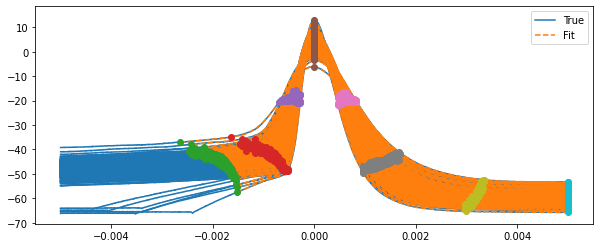

In [4]:
# Plot (warning: very slow for a large number of spikes)
psg.plot()

In [5]:
psg.df_poly.head()

,poly00_c0,poly00_c1,poly01_c0,poly01_c1,poly01_c2,poly01_c3,poly02_c0,poly02_c1,poly02_c2,poly03_c0,poly03_c1,poly03_c2,poly04_c0,poly04_c1,poly04_c2,poly05_c0,poly05_c1,poly05_c2,poly06_c0,poly06_c1
0,-0.002930,-56.279260,-4.045002e-07,0.001861,-2.865297,1416.470217,0.000765,-2.024527,1288.338104,-0.000987,1.836034,-839.441628,-0.005132,10.207099,-5065.950429,0.003248,-5.408828,2207.752366,0.008842,-51.038564
1,-0.002775,-55.868743,-3.601056e-07,0.001682,-2.629207,1316.854295,0.000651,-1.755026,1131.762717,-0.001034,1.961790,-918.541878,-0.004093,8.158586,-4057.624720,0.002601,-4.267217,1708.925346,0.008311,-48.368725
2,-0.002359,-56.204584,-3.692186e-07,0.001732,-2.719148,1369.435462,0.000608,-1.652538,1072.197230,-0.001112,2.141119,-1021.007901,-0.003666,7.334529,-3660.819560,0.002303,-3.754748,1489.682680,0.007034,-46.892886
3,-0.001453,-57.387097,-3.406769e-07,0.001598,-2.511166,1262.443614,0.000643,-1.736178,1121.641002,-0.001032,1.971550,-930.289149,-0.003866,7.713043,-3839.231022,0.002404,-3.921927,1558.467256,0.010379,-49.869223
4,-0.001601,-59.901120,-4.409649e-07,0.002035,-3.139566,1559.098843,0.000804,-2.131354,1361.030557,-0.001269,2.448020,-1168.967325,-0.004694,9.392819,-4689.893836,0.002851,-4.734975,1923.517668,0.008885,-50.064252


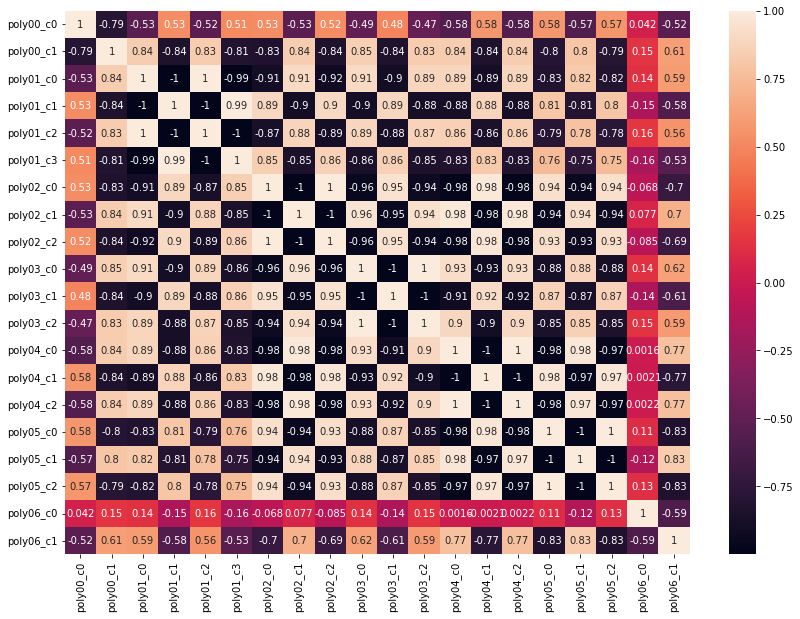

In [6]:
# Plot poly coefficients
fig, ax = plt.subplots(figsize=(14, 10))

spikes_corr = psg.df_poly.corr()

sns.heatmap(spikes_corr, ax=ax, xticklabels=spikes_corr.columns, yticklabels=spikes_corr.columns, annot=True)

plt.show()

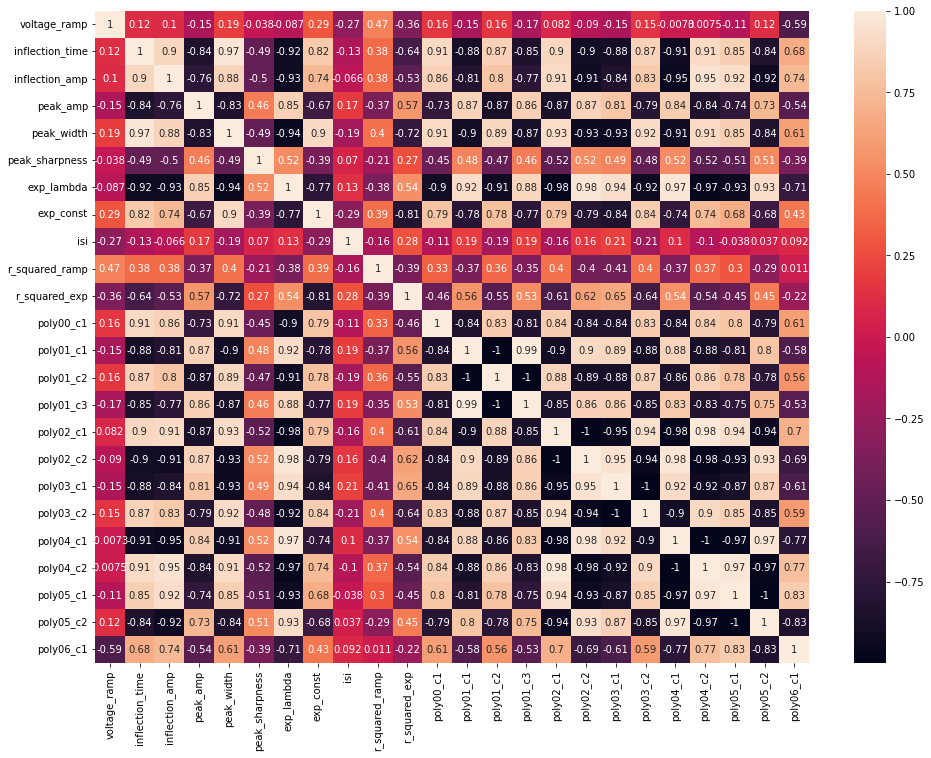

In [7]:
# Remove poly constants
df_poly = psg.df_poly[[i for i in psg.df_poly.columns if 'c0' not in i]]

df_features = psg.df_features
df_features = df_features.drop(columns='group')

# Combine with spike df
df = pd.concat((df_features, df_poly), axis=1)

# Plot
fig, ax = plt.subplots(figsize=(16, 12))

spikes_corr = df.corr()

sns.heatmap(spikes_corr, ax=ax, xticklabels=spikes_corr.columns, yticklabels=spikes_corr.columns, annot=True)

plt.show()